Pre-Processing for Phishing URL Detection

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import resample

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
phishing_websites = fetch_ucirepo(id=327)

# data (as pandas dataframes)
X = phishing_websites.data.features
y = phishing_websites.data.targets

# metadata
print(phishing_websites.metadata)

# variable information
print(phishing_websites.variables)

{'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey', 'venue': 'International Conference for Internet Tec

Step 1: Explore data

In [64]:
print(X.shape)
print(y.shape)

print(X.head())
print(y.head())

print(y.value_counts())

print(phishing_websites.metadata)


(11055, 30)
(11055, 1)
   having_ip_address  url_length  shortining_service  having_at_symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  prefix_suffix  having_sub_domain  sslfinal_state  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   domain_registration_length  favicon  ...  

Step 2: Fix Label Mapping and explore datset

(11055,)
<class 'pandas.core.series.Series'>
result
0    6157
1    4898
Name: count, dtype: int64
(11055, 30) (11055,)


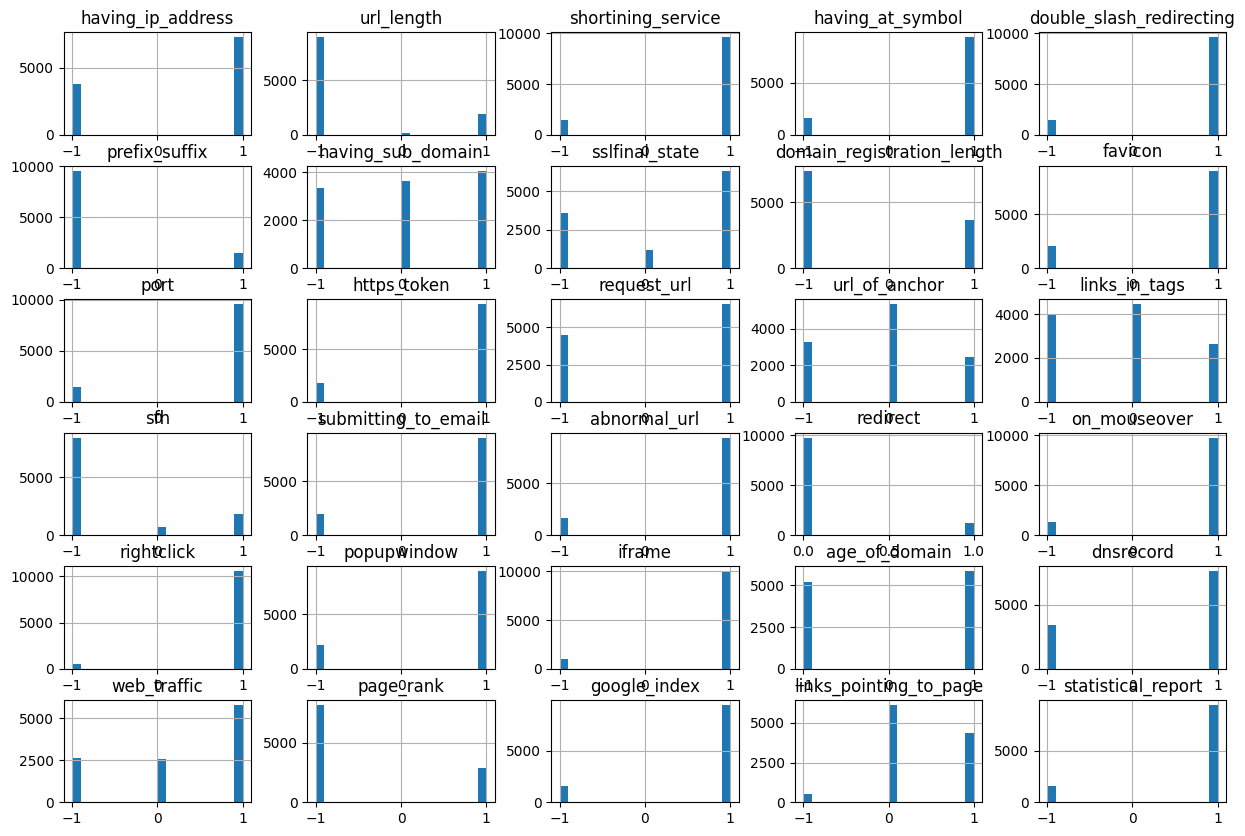

In [65]:
# ---------------------------------------------
# Prepare labels and inspect features
# ---------------------------------------------
# 1. Convert y to a Series and remap labels: phishing = 1, legitimate = 0.
# 2. Confirm dataset shapes and label distribution.
# 3. Inspect feature distributions to check ranges and detect any obvious issues before training.

y = y.squeeze()
print(y.shape)
print(type(y))

# Remap: phishing = 1, legitimate = 0
y = y.replace({-1: 1, 1: 0})

print(y.value_counts())

print(X.shape, y.shape)  # should be (11055, 30) (11055,)


X.describe()

X.hist(figsize=(15,10), bins=20)
plt.show()

Step 3: Train test split

In [66]:
# ---------------------------------------------
# Split data into training and test sets
# ---------------------------------------------
# 1. Use an 80/20 train-test split.
# 2. Stratify by label to preserve phishing vs. legitimate proportions.
# 3. Print shapes and label counts to verify the split.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(), y_test.value_counts())

(8844, 30) (2211, 30)
result
0    4926
1    3918
Name: count, dtype: int64 result
0    1231
1     980
Name: count, dtype: int64


Step 4: Feature scaling

In [67]:
# ---------------------------------------------
# Feature scaling
# ---------------------------------------------
# Standardize features to zero mean and unit variance.
# This is important for models sensitive to feature magnitude (e.g., Logistic Regression, SVM).
# Fit scaler on training data and apply the same transformation to test data.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 5: Handling class imbalance

In [68]:
# ---------------------------------------------
# Handle class imbalance
# ---------------------------------------------
# Assign weights to classes to compensate for moderate imbalance in the dataset.
# Here, phishing (1) is slightly underrepresented, so it gets a higher weight relative to legitimate (0).

class_weight = {0: 1, 1: 6157/4898}

Step 6: Exploratory Data Analysis

In [69]:
# ---------------------------------------------
# Quick exploratory check of feature distributions by class
# ---------------------------------------------
# Combine X_train and y_train into a single DataFrame for EDA.
# Compute mean values of each feature for phishing vs. legitimate classes
# to get a sense of which features differ between classes.

import seaborn as sns

train_df = X_train.copy()
train_df['label'] = y_train

print(train_df.groupby('label').mean())

       having_ip_address  url_length  shortining_service  having_at_symbol  \
label                                                                        
0               0.398701   -0.592773            0.700771          0.726350   
1               0.220521   -0.682746            0.791730          0.660541   

       double_slash_redirecting  prefix_suffix  having_sub_domain  \
label                                                               
0                      0.719042       -0.53309           0.281161   
1                      0.772843       -1.00000          -0.202910   

       sslfinal_state  domain_registration_length   favicon  ...  rightclick  \
label                                                        ...               
0            0.834145                   -0.523752  0.618352  ...    0.920828   
1           -0.475753                   -0.097499  0.636549  ...    0.910669   

       popupwindow    iframe  age_of_domain  dnsrecord  web_traffic  \
label             

In [70]:
# ---------------------------------------------
# Identify key features for phishing detection
# ---------------------------------------------
# Compute correlations of all features with the target label.
# Inspect top features using cross-tabulations to see the distribution
# of feature values across phishing (1) and legitimate (0) classes.

top_features = ['sslfinal_state', 'prefix_suffix', 'shortining_service',
                'having_at_symbol', 'double_slash_redirecting']

correlations = train_df.corr()['label'].sort_values(ascending=False)
print(correlations.head(10))

for col in top_features:
    print(f"\nFeature: {col}")
    print(pd.crosstab(train_df[col], train_df['label']))

label                         1.000000
domain_registration_length    0.224715
shortining_service            0.067294
abnormal_url                  0.063019
double_slash_redirecting      0.039923
https_token                   0.039790
redirect                      0.013674
favicon                       0.011597
popupwindow                   0.010622
iframe                        0.008608
Name: label, dtype: float64

Feature: sslfinal_state
label              0     1
sslfinal_state            
-1               401  2429
 0                15   924
 1              4510   565

Feature: prefix_suffix
label             0     1
prefix_suffix            
-1             3776  3918
 1             1150     0

Feature: shortining_service
label                  0     1
shortining_service            
-1                   737   408
 1                  4189  3510

Feature: having_at_symbol
label                0     1
having_at_symbol            
-1                 674   665
 1                4252  325

Step 7: Dimensionality Reduction

In [71]:
# ---------------------------------------------
# Dimensionality reduction using PCA
# ---------------------------------------------
# Reduce feature space while retaining 95% of variance.
# This can improve efficiency and reduce redundancy for certain models.

from sklearn.decomposition import PCA

# Initialize PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components to retain 95% variance:", X_train_pca.shape[1])

Original number of features: 30
Number of PCA components to retain 95% variance: 23


Step 8: Feature Importance Analysis

In [72]:
# ---------------------------------------------
# Train a logistic regression model
# ---------------------------------------------
# Fit a baseline logistic regression with class balancing.
# Extract and display the top 10 features by absolute coefficient
# to understand which inputs contribute most to predictions.

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

print(coef_df.head(10))

                   feature  coefficient
13           url_of_anchor    -2.260538
5            prefix_suffix    -2.162262
7           sslfinal_state    -1.482308
15                     sfh    -0.715456
14           links_in_tags    -0.620655
0        having_ip_address    -0.617318
25             web_traffic    -0.599914
6        having_sub_domain    -0.508487
2       shortining_service     0.497527
28  links_pointing_to_page    -0.475354


In [73]:
# ---------------------------------------------
# Train a Random Forest model
# ---------------------------------------------
# Fit a Random Forest classifier with class balancing.
# Extract and display the top 10 most important features
# according to the model to evaluate feature relevance.

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

# Feature importance
rf_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(rf_importances.head(10))

                       feature  importance
7               sslfinal_state    0.321014
13               url_of_anchor    0.239925
25                 web_traffic    0.074547
6            having_sub_domain    0.064946
5                prefix_suffix    0.046953
14               links_in_tags    0.044050
15                         sfh    0.022145
12                 request_url    0.018736
28      links_pointing_to_page    0.018424
8   domain_registration_length    0.015890


Things done in this pre-processing notebook:



1.   Label remapping: mapped phishing = 1, legitimate = 0 consistently.

3. Train–test split: Stratified, so class proportions are preserved.

3. Feature scaling/normalization: Done for LR and SVM with StandardScaler.

4. Class imbalance handling: set class weights for the supervised models.

5. Exploratory data analysis: Histograms, correlation checks, crosstabs, top features.

6. Dimensionality reduction: Optional PCA identified 23 components for 95% variance.

7. Feature importance/interpretability: Checked LR coefficients and Random Forest importances.

